In [8]:
import numpy as np


In [5]:

def load_results_subject(subject_index =2):
    data = np.load(f"subject_{subject_index}_results.pkl", allow_pickle=True)
    return data

In [ ]:
def load_results_all_subjects():
    data = []
    for i in range(1, 11):
        data.append(load_results_subject(i))
    return data

In [15]:
def load_results_all_subjects():
    subjects = [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
    data = {}
    for i in subjects:
        data[i] = load_results_subject(i)
    return data

In [16]:
all_subjects_results = load_results_all_subjects()

In [29]:
all_subjects_results[1].keys()

dict_keys(['DeepLift', 'IntegratedGradients', 'GradientShap', 'Saliency'])

In [40]:
len(all_subjects_results[2]["DeepLift"]["Randomisation"])


571

In [43]:
all_subjects_results[2]["DeepLift"]["Randomisation"][300]["cross_trial_s4.channel_mixer.1"][0]

0.5558768393630598

In [71]:
import matplotlib.pyplot as plt

def plot_average_results(all_subjects_results, explanation_methods =["Saliency", "IntegratedGradients", "GradientShap", "DeepLift"]):

    # If no explanation methods provided, use all available ones
    colors = ['b', 'r', 'g', "y"]
    markers = ['o', 's', 'p', "P"]
    
    fig, ax = plt.subplots(figsize=(16, 8))
    all_layer_results = {e: {} for e in explanation_methods}
    all_layer_results_mean = {e: {} for e in explanation_methods}
    all_layer_results_std = {e: {} for e in explanation_methods}
    layers = list(all_subjects_results[1][explanation_methods[0]]["Randomisation"][0].keys())
    layers.remove('original')
    for layer in layers:
        for method in explanation_methods:
            all_layer_results[method][layer] = []
            all_layer_results_mean[method][layer] = 0
            all_layer_results_std[method][layer] = 0

    # Set x-tick labels
    plt.xticks(np.arange(len(layers)), layers, rotation=90)
    for i, method in enumerate(explanation_methods):
        for layer in layers:
            for subject_id, subject_data in all_subjects_results.items():
                for trial in range(len(subject_data[method]["Randomisation"])):
                    all_layer_results[method][layer].append(subject_data[method]["Randomisation"][trial][layer][0])
            all_layer_results[method][layer] = np.array(all_layer_results[method][layer])
            all_layer_results_mean[method][layer] = np.mean(all_layer_results[method][layer])
            all_layer_results_std[method][layer] = np.std(all_layer_results[method][layer])

        ax.plot(np.arange(len(layers)), all_layer_results_mean[method].values(), label=method, color=colors[i], marker=markers[i])
        ax.fill_between(np.arange(len(layers)),
                        np.array(list(all_layer_results_mean[method].values())) - np.array(list(all_layer_results_std[method].values())),
                        np.array(list(all_layer_results_mean[method].values())) + np.array(list(all_layer_results_std[method].values())),
                        alpha=0.2, color=colors[i])
    ax.legend()
    plt.show()



    #axs[idx,0].plot(amplification_factors, swd_means, 'o-', label='SWD', color='blue')
    #axs[idx,0].fill_between(amplification_factors, 
    #                       np.array(swd_means) - np.array(swd_std),
    #                       np.array(swd_means) + np.array(swd_std),
    #                       alpha=0.2, color='blue')


    


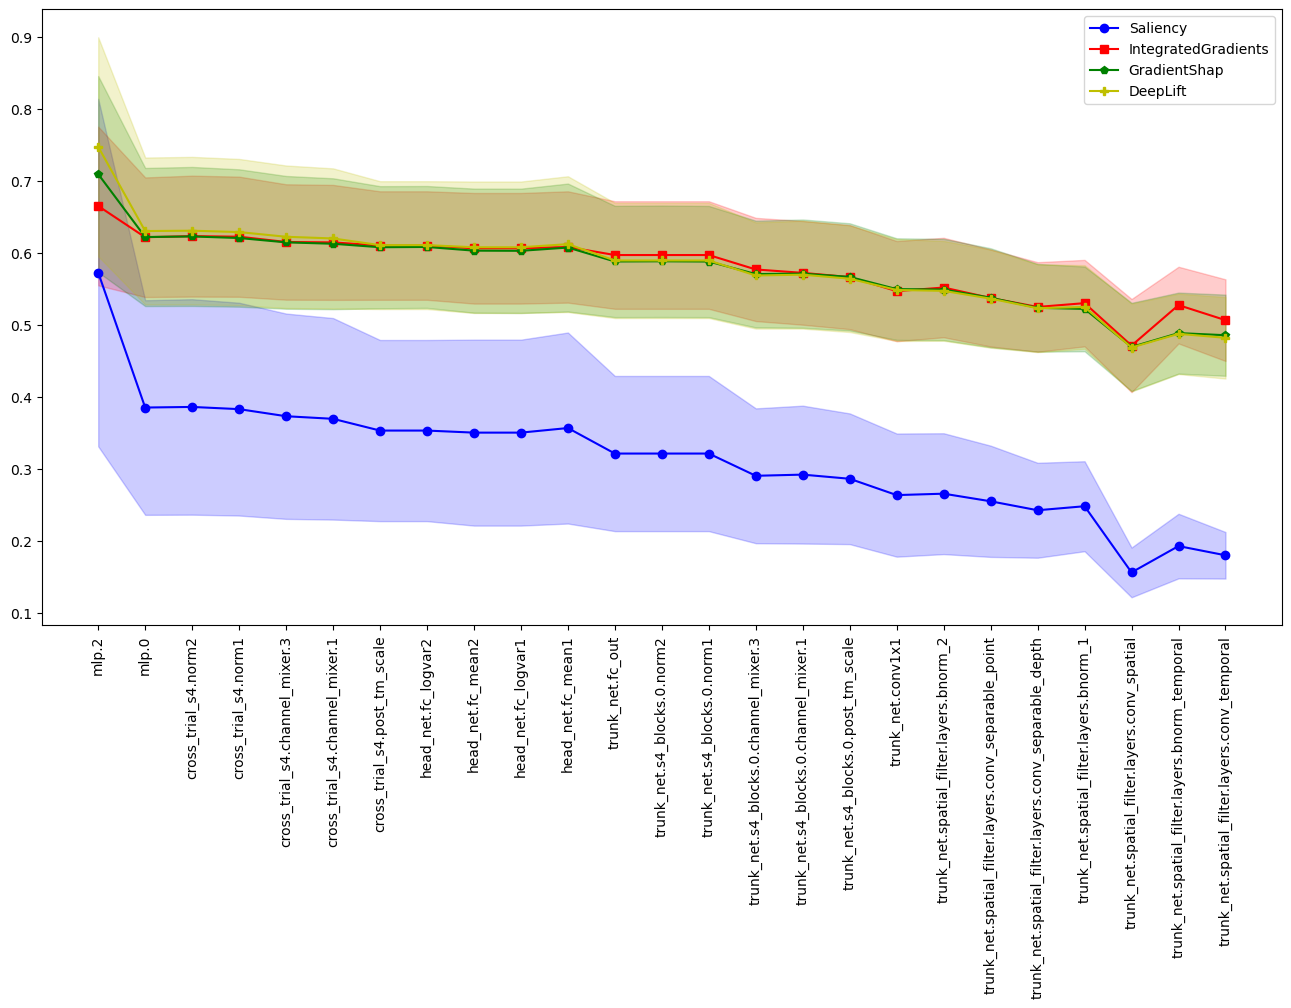

In [72]:
plot_average_results(all_subjects_results)